# Python coding skills for statistics Part 3

Python libraries for doing statistics

see draft here: https://docs.google.com/document/d/1a-Ohl3hs7w8AiOr85PxW0DZP1ofFK02sk55IEw0zQPE/edit?tab=t.0

 

## Data management with Pandas

## Numerical computing with NumPy

## Scientific computing with SciPy

## Data visualization with Seaborn

## Frequentist statistics with Statsmodels

## Honorable mention: pingouin

## Bayesian statistics with Bambi (based on PyMC)

## Statistics procedures as readable code (ministats)

### Generating sampling distributions

In [42]:
from ministats import gen_sampling_dist

%psource gen_sampling_dist

def gen_sampling_dist(rv, estfunc, n, N=10000):
    """
    Simulate `N` samples of size `n` from the random variable `rv` to
    generate the sampling distribution of the estimator `estfunc`.
    """
    estimates = []
    for i in range(0, N):
        sample = rv.rvs(n)
        estimate = estfunc(sample)
        estimates.append(estimate)
    return estimates


### One-sample t-test for the mean

In [43]:
from ministats import ttest_mean
%psource ttest_mean

def ttest_mean(sample, mu0, alt="two-sided"):
    """
    T-test to detect mean deviation from a population with known mean `mu0`.
    """
    assert alt in ["greater", "less", "two-sided"]
    obsmean = np.mean(sample)
    n = len(sample)
    std = np.std(sample, ddof=1)
    sehat = std / np.sqrt(n)
    obst = (obsmean - mu0) / sehat
    rvT = tdist(df=n-1)
    pvalue = tailprobs(rvT, obst, alt=alt)
    return pvalue


### Generating bootstrap distributions

In [44]:
from ministats import gen_boot_dist

%psource gen_boot_dist

def gen_boot_dist(sample, estfunc, B=5000):
    """
    Generate estimates from the sampling distribution of the estimator `estfunc`
    based on `B` bootstrap samples (sampling with replacement) from `sample`.
    """
    n = len(sample)
    bestimates = []
    for i in range(0, B):
        bsample = np.random.choice(sample, n, replace=True)
        bestimate = estfunc(bsample)
        bestimates.append(bestimate)
    return bestimates


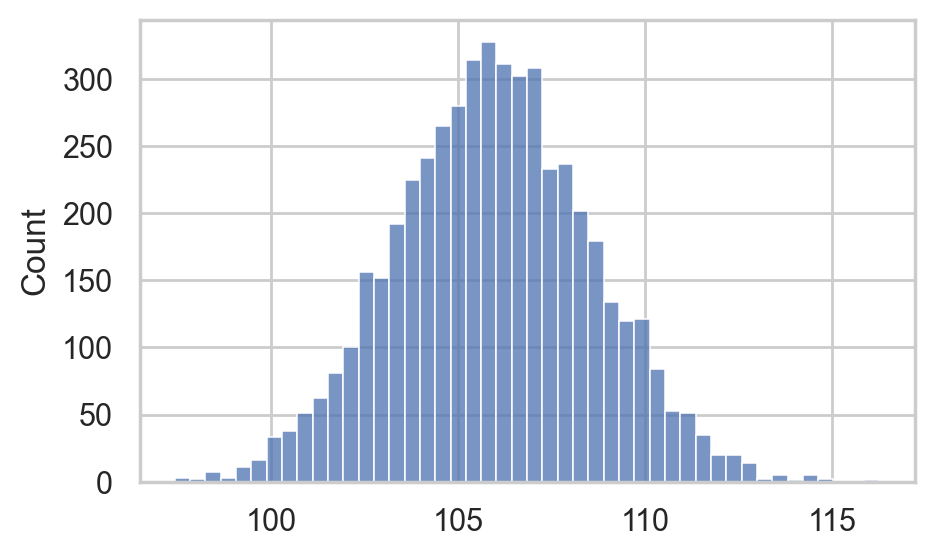

In [45]:
iqs_boot = gen_boot_dist(iqs, estfunc=mean)
sns.histplot(iqs_boot);

### The permutation test for comparing two groups

In [46]:
from ministats.hypothesis_tests import resample_under_H0
from ministats import permutation_test_dmeans

%psource permutation_test_dmeans

def permutation_test_dmeans(xsample, ysample, P=10000):
    """
    Compute the p-value of the observed difference between means
    `dmeans(xsample,ysample)` under the null hypothesis where
    the group membership is randomized.
    """
    # 1. Compute the observed difference between means
    obsdhat = dmeans(xsample, ysample)

    # 2. Get sampling dist. of `dmeans` under H0
    pdhats = []
    for i in range(0, P):
        rsx, rsy = resample_under_H0(xsample, ysample)
        pdhat = dmeans(rsx, rsy)
        pdhats.append(pdhat)

    # 3. Compute the p-value
    tails = tailvalues(pdhats, obsdhat)
    pvalue = len(tails) / len(pdhats)
    return pvalue


In [47]:
%psource resample_under_H0

def resample_under_H0(xsample, ysample):
    """
    Generate new samples from a random permutation of
    the values in the samples `xsample` and `ysample`.
    """
    values = np.concatenate((xsample, ysample))
    shuffled_values = np.random.permutation(values)
    xresample = shuffled_values[0:len(xsample)]
    yresample = shuffled_values[len(xsample):]
    return xresample, yresample


In [48]:
np.random.seed(43)
permutation_test_dmeans(treated, controls)

0.0098


See the [`ministats`](https://github.com/minireference/ministats/tree/main/ministats) library
for more examples of Python functions that implement the statistical procedures in STATS 101.

In the past, students first contact with statistics was presented as a bunch of procedures
without explanation, and students were supposed to memorize when to use which "recipe".
Statistics instructors always had to "skip the details" because it's super complicated to
explain all the details (probability models, sampling distributions, p-value calculations, etc.).

Now that we have Python on our side, we don't have to water-down the material,
but can instead show all the detailed calculations for statistical tests,
as easy-to-understand Python source code, which makes it much much easier to understand what is going on.
Currently,
the [`ministats`](https://github.com/minireference/ministats/tree/main/ministats) library contains about 400 lines of code.
With a little bit of Python knowledge,
you can read the source code and understand all of statistics.